# <center> <h1>   ⦿ ⚫ ⚪   🧑‍💻   ⚪ ⚫ ⦿ 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

# K-Means

K-Means Clustering is an Unsupervised Learning algorithm, which groups the unlabeled dataset into different clusters. Here K defines the number of pre-defined clusters that need to be created in the process, as if K=2, there will be two clusters, and for K=3, there will be three clusters, and so on.

It is an iterative algorithm that divides the unlabeled dataset into k different clusters in such a way that each dataset belongs only one group that has similar properties.

It allows us to cluster the data into different groups and a convenient way to discover the categories of groups in the unlabeled dataset on its own without the need for any training.

It is a centroid-based algorithm, where each cluster is associated with a centroid. The main aim of this algorithm is to minimize the sum of distances between the data point and their corresponding clusters.

<img src="Photo/k-means.png">

# Data

## Create random data

In [25]:
a1 = np.random.randint(1,10, size=(5,2))
a2 = np.random.randint(7,15, size=(5,2))
a3 = np.random.randint(12,20, size=(5,2))

In [26]:
a1

array([[8, 5],
       [2, 7],
       [9, 5],
       [4, 1],
       [5, 6]])

In [27]:
a2

array([[11,  9],
       [14, 11],
       [ 9,  9],
       [12,  9],
       [11,  7]])

In [28]:
a3

array([[12, 14],
       [15, 18],
       [14, 17],
       [15, 12],
       [18, 13]])

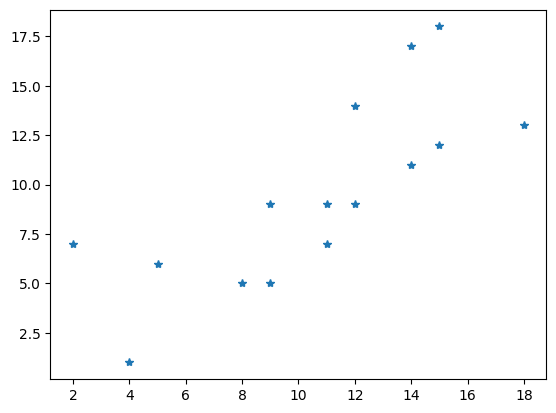

In [167]:
a = np.concatenate((a1,a2,a3),axis=0)
plt.plot(a[:,0],a[:,1],"*")
# show data

In [30]:
a = np.float32(a)     # convert data type npfloat32
a

array([[ 8.,  5.],
       [ 2.,  7.],
       [ 9.,  5.],
       [ 4.,  1.],
       [ 5.,  6.],
       [11.,  9.],
       [14., 11.],
       [ 9.,  9.],
       [12.,  9.],
       [11.,  7.],
       [12., 14.],
       [15., 18.],
       [14., 17.],
       [15., 12.],
       [18., 13.]], dtype=float32)

# K=3

In [118]:
# criteria = ( type, max_iter = 10 , epsilon = 1.0 )
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,10,0.1)  

# cv.TERM_CRITERIA_EPS - stop the algorithm iteration if specified accuracy, epsilon, is reached.
# cv.TERM_CRITERIA_MAX_ITER - stop the algorithm after the specified number of iterations, max_iter.
# cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER - stop the iteration when any of the above condition is met.


k=3

compactness , label, center = cv2.kmeans(a,k,None,criteria,10,cv2.KMEANS_RANDOM_CENTERS)


` compactness : It is the sum of squared distance from each point to their corresponding centers. `

In [119]:
compactness

114.83332967758179

` labels : This is the label array where each element marked '0', '1'..... `

In [120]:
label

array([[2],
       [0],
       [2],
       [0],
       [0],
       [2],
       [1],
       [2],
       [2],
       [2],
       [1],
       [1],
       [1],
       [1],
       [1]], dtype=int32)

` Centers : This is array of centers of clusters. `

In [121]:
center

array([[ 3.6666667,  4.666667 ],
       [14.666667 , 14.166667 ],
       [10.       ,  7.3333335]], dtype=float32)

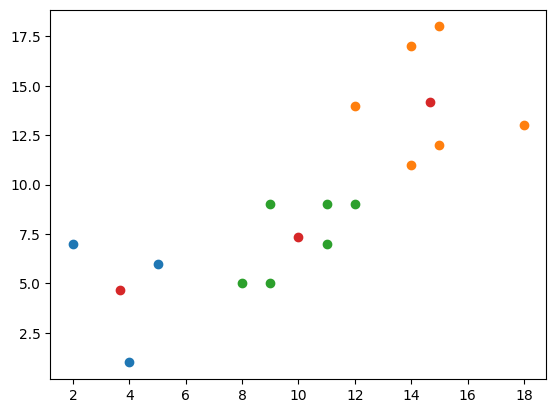

In [122]:
a1 = a[label.flatten()==0]
a2 = a[label.flatten()==1]
a3 = a[label.flatten()==2]

plt.scatter(a1[:,0],a1[:,1])
plt.scatter(a2[:,0],a2[:,1])
plt.scatter(a3[:,0],a3[:,1])

plt.scatter(center[:,0],center[:,1])

#3 points belong to the 1st class (green).
#6 points belong to the 2nd class (yellow).
#6 points belong to the 3rd class (blue)

# K=2

In [129]:
# criteria = ( type, max_iter = 10 , epsilon = 1.0 )
criteria2 = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,10,0.1)  

# cv.TERM_CRITERIA_EPS - stop the algorithm iteration if specified accuracy, epsilon, is reached.
# cv.TERM_CRITERIA_MAX_ITER - stop the algorithm after the specified number of iterations, max_iter.
# cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER - stop the iteration when any of the above condition is met.


k=2

compactness2, label2, center2 = cv2.kmeans(a,k,None,criteria,10,cv2.KMEANS_RANDOM_CENTERS)


In [130]:
compactness2

209.2777760028839

In [131]:
label2

array([[0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1]], dtype=int32)

In [132]:
center2

array([[ 7.888889 ,  6.4444447],
       [14.666667 , 14.166667 ]], dtype=float32)

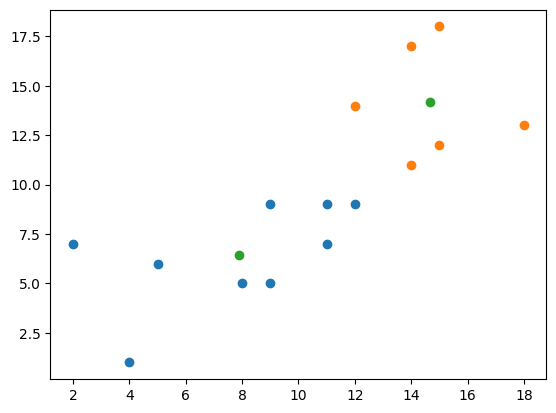

In [133]:
a11 = a[label2.flatten()==0]
a22 = a[label2.flatten()==1]


plt.scatter(a11[:,0],a11[:,1])
plt.scatter(a22[:,0],a22[:,1])


plt.scatter(center2[:,0],center2[:,1])

#9 points belong to the 1st class (yellow).
#6 points belong to the 2nd class (blue).

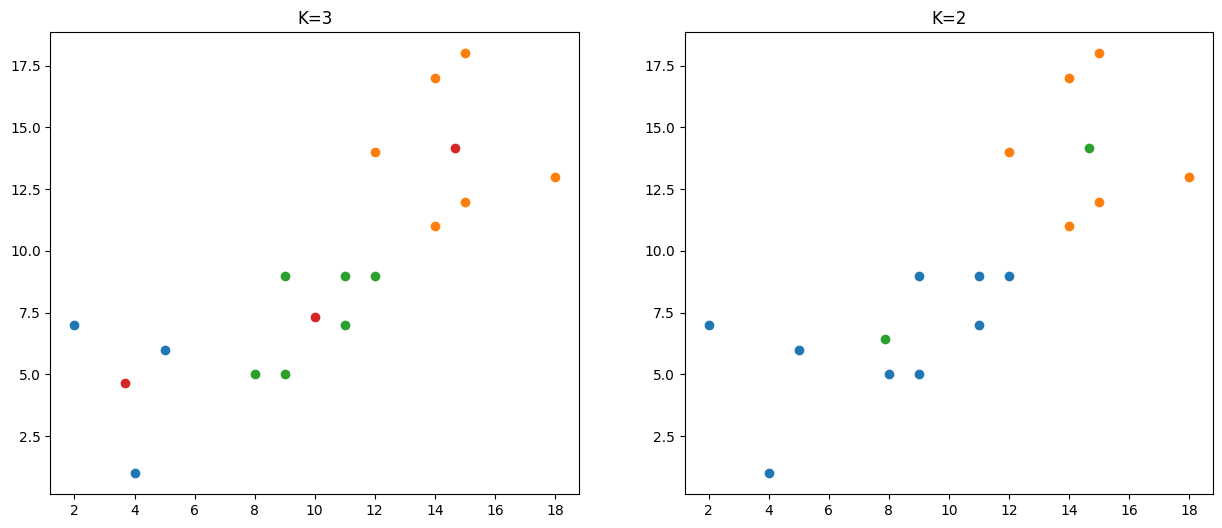

In [136]:
plt.figure(figsize=(15,6))

plt.subplot(121)
plt.title("K=3")
a1 = a[label.flatten()==0]
a2 = a[label.flatten()==1]
a3 = a[label.flatten()==2]

plt.scatter(a1[:,0],a1[:,1])
plt.scatter(a2[:,0],a2[:,1])
plt.scatter(a3[:,0],a3[:,1])

plt.scatter(center[:,0],center[:,1])



plt.subplot(122)
plt.title("K=2")
a11 = a[label2.flatten()==0]
a22 = a[label2.flatten()==1]

plt.scatter(a11[:,0],a11[:,1])
plt.scatter(a22[:,0],a22[:,1])

plt.scatter(center2[:,0],center2[:,1])


# Image

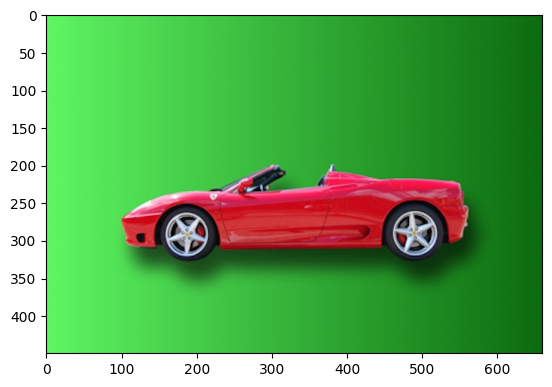

In [139]:
img = cv2.imread("Photo/car_green.jpg")     #load images from local file
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  #convert image from bgr to rgb   
plt.imshow(img)     #show the picture

In [140]:
img[:,:,0]

array([[94, 94, 94, ..., 12, 13, 13],
       [94, 94, 94, ..., 13, 12, 12],
       [94, 94, 94, ..., 13, 12, 12],
       ...,
       [94, 94, 94, ..., 11, 11, 11],
       [94, 94, 94, ..., 13, 12, 12],
       [94, 94, 94, ..., 13, 12, 12]], dtype=uint8)

In [141]:
img[:,:,1]

array([[246, 246, 246, ..., 107, 108, 108],
       [246, 246, 246, ..., 108, 107, 107],
       [246, 246, 246, ..., 108, 107, 107],
       ...,
       [246, 246, 246, ..., 108, 108, 108],
       [246, 246, 246, ..., 108, 107, 107],
       [246, 246, 246, ..., 108, 107, 107]], dtype=uint8)

In [142]:
img[:,:,2]

array([[99, 99, 99, ..., 15, 16, 16],
       [99, 99, 99, ..., 16, 15, 15],
       [99, 99, 99, ..., 16, 15, 15],
       ...,
       [99, 99, 99, ..., 15, 15, 15],
       [99, 99, 99, ..., 16, 15, 15],
       [99, 99, 99, ..., 16, 15, 15]], dtype=uint8)

In [143]:
img.shape

(450, 660, 3)

In [144]:
img_ = img.reshape(-1,3)
img_.shape

(297000, 3)

In [145]:
img_ = np.float32(img_)
img_

array([[ 94., 246.,  99.],
       [ 94., 246.,  99.],
       [ 94., 246.,  99.],
       ...,
       [ 13., 108.,  16.],
       [ 12., 107.,  15.],
       [ 12., 107.,  15.]], dtype=float32)

# K=3

In [146]:
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,10,0.1)

k=3

compactness, label, center = cv2.kmeans(img_, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)


In [147]:
compactness

527684082.3759482

In [149]:
label

array([[1],
       [1],
       [1],
       ...,
       [0],
       [0],
       [0]], dtype=int32)

In [150]:
center

array([[ 29.331533, 125.30738 ,  32.26491 ],
       [ 76.54439 , 210.06181 ,  80.88128 ],
       [202.65184 ,  44.53712 ,  65.25879 ]], dtype=float32)

In [151]:
center = np.uint8(center)
center

array([[ 29, 125,  32],
       [ 76, 210,  80],
       [202,  44,  65]], dtype=uint8)

In [152]:
label.shape

(297000, 1)

In [153]:
label = label.reshape(img.shape[0], img.shape[1])
label.shape

(450, 660)

In [154]:
k_means_img = center[label.flatten()]
k_means_img

array([[ 76, 210,  80],
       [ 76, 210,  80],
       [ 76, 210,  80],
       ...,
       [ 29, 125,  32],
       [ 29, 125,  32],
       [ 29, 125,  32]], dtype=uint8)

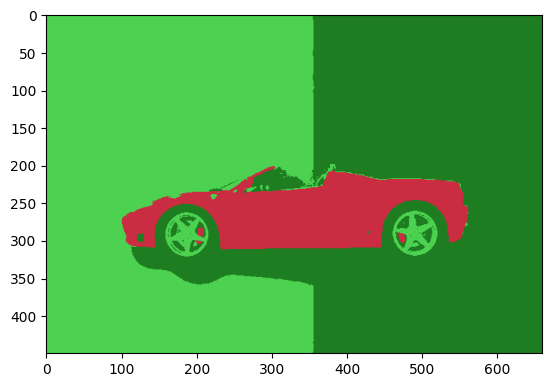

In [155]:
k_means_img = k_means_img.reshape(img.shape)
plt.imshow(k_means_img)

# K=2

In [156]:
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,10,0.1)

k=2

compactness, label, center = cv2.kmeans(img_reshaped, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)


In [157]:
compactness

1306016021.2878325

In [158]:
label

array([[1],
       [1],
       [1],
       ...,
       [1],
       [1],
       [1]], dtype=int32)

In [159]:
center

array([[198.44534 ,  60.612286,  79.7933  ],
       [ 51.213463, 167.85094 ,  54.799126]], dtype=float32)

In [160]:
center = np.uint8(center)
center

array([[198,  60,  79],
       [ 51, 167,  54]], dtype=uint8)

In [161]:
label.shape

(297000, 1)

In [162]:
label = label.reshape(img.shape[0], img.shape[1])
label.shape

(450, 660)

In [163]:
k_means_img2 = center[label.flatten()]
k_means_img2

array([[ 51, 167,  54],
       [ 51, 167,  54],
       [ 51, 167,  54],
       ...,
       [ 51, 167,  54],
       [ 51, 167,  54],
       [ 51, 167,  54]], dtype=uint8)

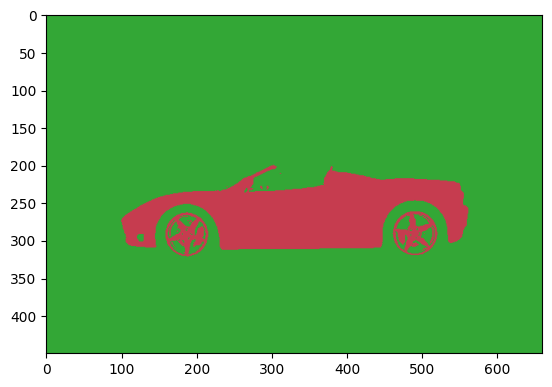

In [164]:
k_means_img2 = k_means_img2.reshape(img.shape)
plt.imshow(k_means_img2)

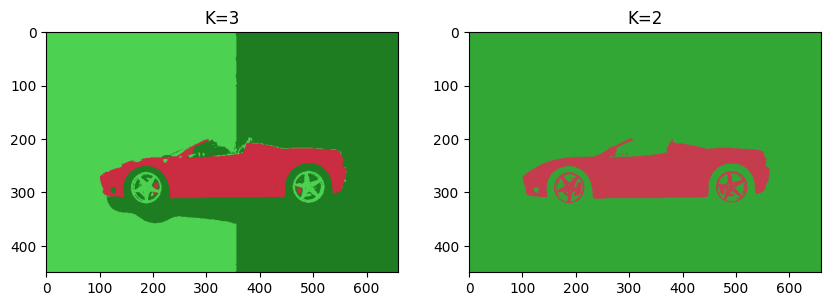

In [166]:
plt.figure(figsize=(10,6))

plt.subplot(121)
plt.title("K=3")
plt.imshow(k_means_img)

plt.subplot(122)
plt.title("K=2")
plt.imshow(k_means_img2)

# <center> <h1> 👨‍💻   🚀  